In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

close = pd.read_parquet("close_prices.parquet")
daily_returns = pd.read_parquet("daily_returns.parquet")
annual_summary = pd.read_parquet("annual_summary.parquet")

annual_summary.head()

,Annual Return,Annual Volatility
Ticker,,
AAPL,0.274140,0.284618
ABBV,0.176769,0.266563
ABT,0.139571,0.235883
ACN,0.185399,0.248836
ADBE,0.237389,0.331771


Reads and extracts saved files from previous data cleaning notebook, so that we dont have to call yfinance to retreive all data again.

Text(0, 0.5, 'Annual Return')

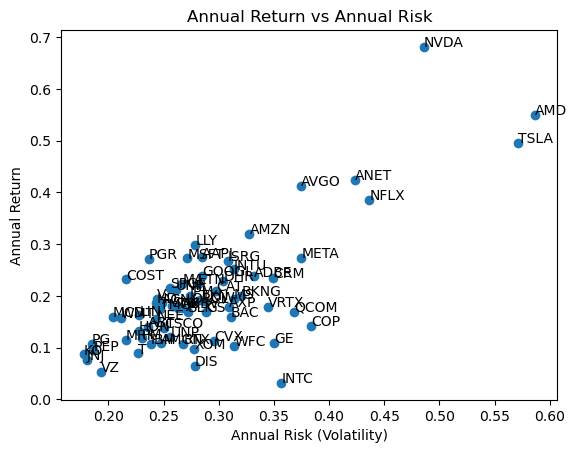

In [3]:
plt.figure()

plt.scatter(annual_summary["Annual Volatility"], annual_summary["Annual Return"])

for ticker in annual_summary.index:
    plt.text(annual_summary["Annual Volatility"][ticker], annual_summary["Annual Return"][ticker],ticker)

plt.title("Annual Return vs Annual Risk")
plt.xlabel("Annual Risk (Volatility)")
plt.ylabel("Annual Return")

Plotting Annual Return Vs Annual Risk as a scatter allows us to identify low risk, high return stocks (bottom left).

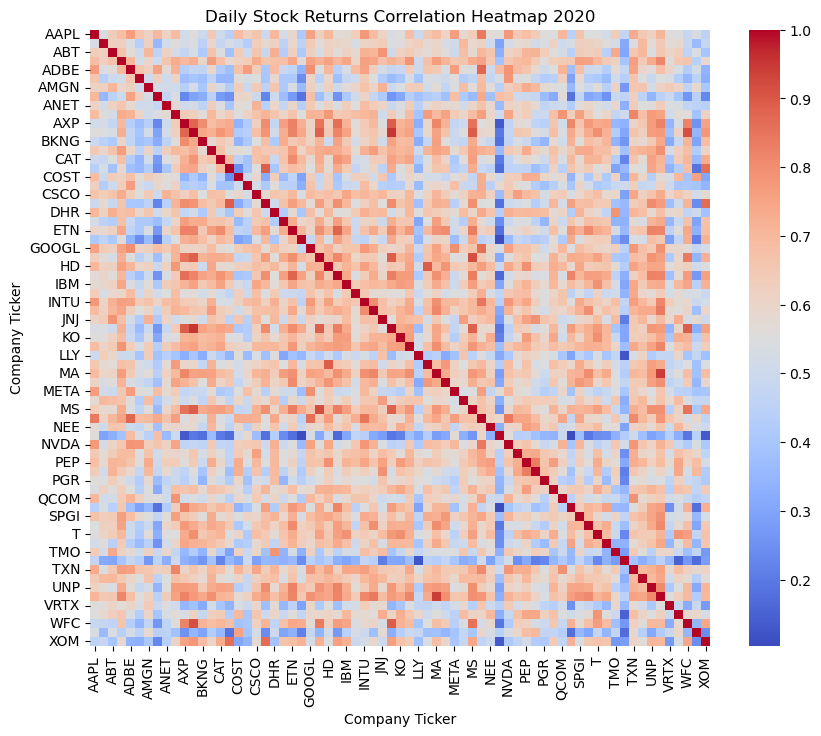

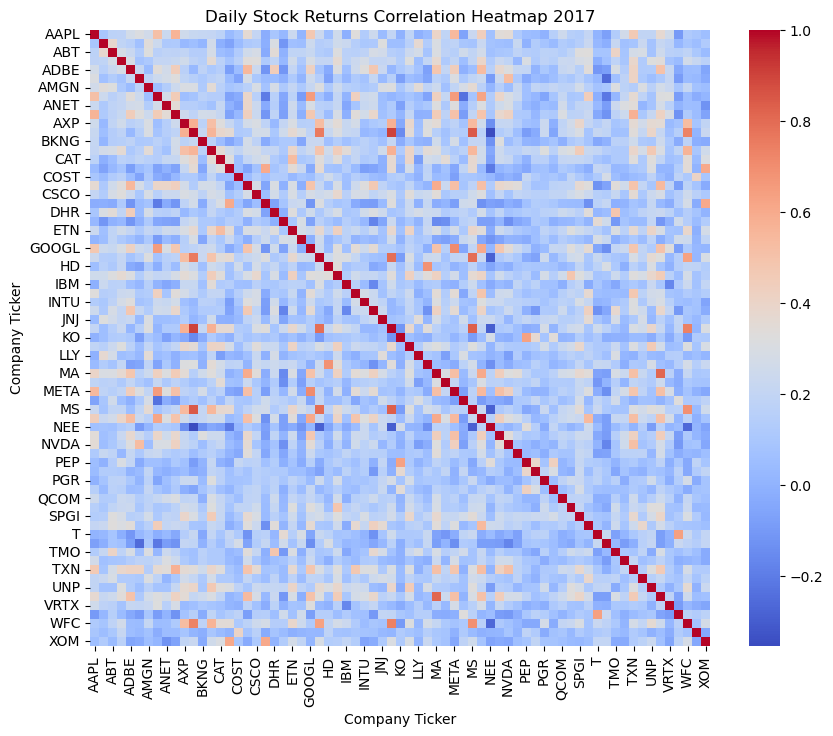

In [10]:
returns_2020 = daily_returns.loc["2020"]
returns_2017 = daily_returns.loc["2017"]
corr_volat = returns_2020.corr()
corr_stable = returns_2017.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_volat, cmap="coolwarm")
plt.title("Daily Stock Returns Correlation Heatmap 2020")
plt.xlabel("Company Ticker")
plt.ylabel("Company Ticker")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(corr_stable, cmap="coolwarm")
plt.title("Daily Stock Returns Correlation Heatmap 2017")
plt.xlabel("Company Ticker")
plt.ylabel("Company Ticker")
plt.show()

Correlation is defined as how two values move together:  
> +1 Moves perfectly      
> 0 No relationship  
> -1 Moves Perfectly Opposite  

Heatmaps uses colours to represent correlation (of returns).
High correlation (less blue) is seen during crises (Market crashes etc)
Low Correlation (more blue) is seen during normal market times

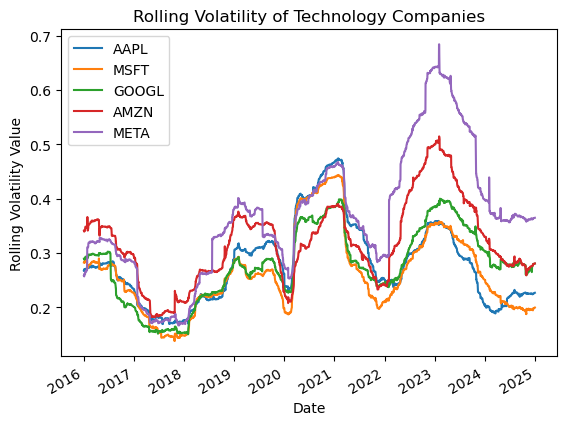

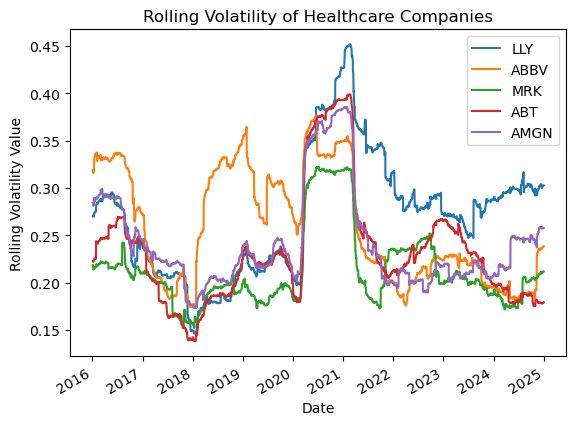

In [11]:
rolling_vol_252 = daily_returns.rolling(window=252).std() * np.sqrt(252)

rolling_vol_252[["AAPL", "MSFT", "GOOGL", "AMZN", "META"]].plot()
plt.title("Rolling Volatility of Technology Companies")
plt.ylabel("Rolling Volatility Value")
plt.legend().set_visible(True)

rolling_vol_252[["LLY", "ABBV", "MRK", "ABT", "AMGN"]].plot()
plt.title("Rolling Volatility of Healthcare Companies")
plt.ylabel("Rolling Volatility Value")
plt.legend().set_visible(True)

These plots show the rolling volatility of companies grouped by industry they share. 
We look at the tech and healthacre industries and see that the rolling volatilities follow similar trends to companies in the same industry, but the two graphs themselves do not follow similar trends.

Text(0, 0.5, 'Drawdowns')

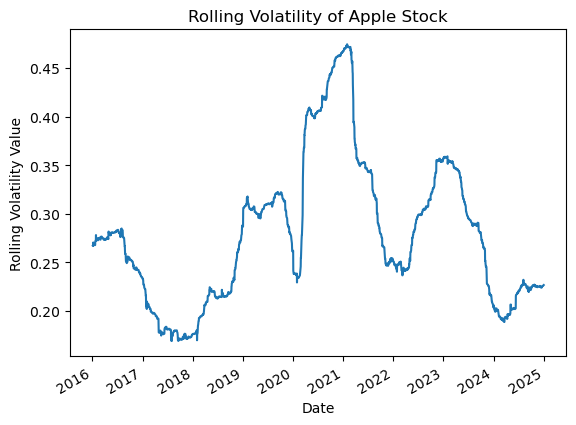

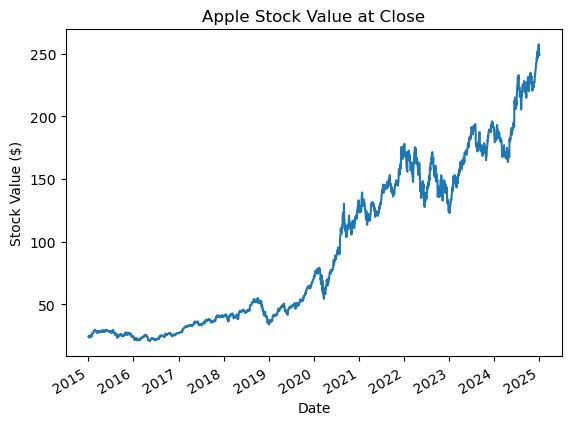

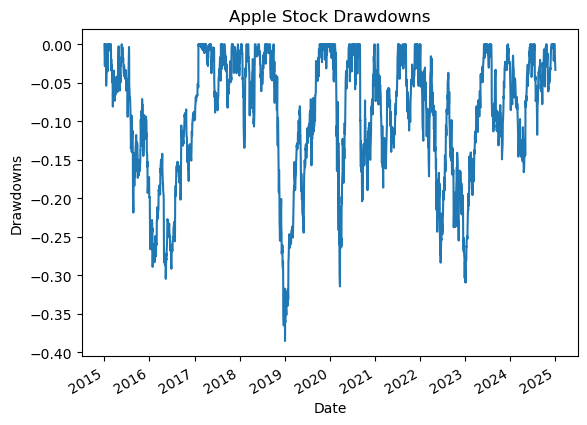

In [6]:
appl_close = close["AAPL"]

rolling_max = appl_close.cummax()

rolling_vol_252["AAPL"].plot()
plt.title("Rolling Volatility of Apple Stock")
plt.ylabel("Rolling Volatility Value")

plt.figure()
appl_close.plot()
plt.title("Apple Stock Value at Close")
plt.ylabel("Stock Value ($)")

plt.figure()
drawdown = (appl_close / rolling_max) - 1
drawdown.plot()
plt.title("Apple Stock Drawdowns")
plt.ylabel("Drawdowns")

Drawdown tell how much a stock has dropped from its highest value so far.
This works well when a stock is increasing constitantly and gives us a measure of **physcological risk**. 
Drawdown shows loss as a percentage of deviation from the previous highest value.

GE 2020-05-15 00:00:00 -0.8119141113243373
META 2022-11-03 00:00:00 -0.76736092963222
NFLX 2022-05-11 00:00:00 -0.759473182516135
TSLA 2023-01-03 00:00:00 -0.736322174421912
COP 2020-03-18 00:00:00 -0.7066103280677373


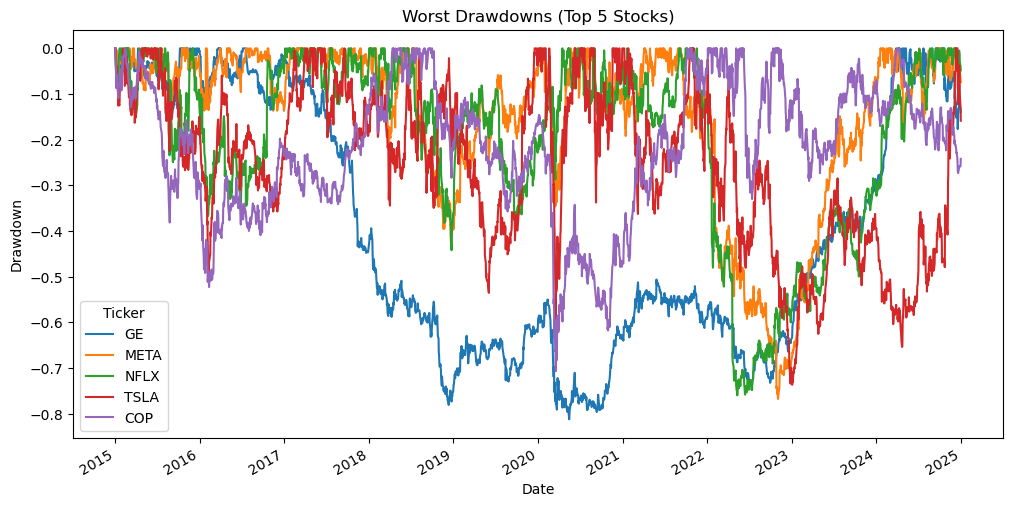

In [7]:
max_drawdowns = ((close / close.cummax()) - 1).min()
worst = max_drawdowns.nsmallest(n=5).index
drawdowns_worst = (close[worst] / close[worst].cummax())  - 1 

for ticker in worst:
    date = drawdowns_worst[ticker].idxmin()
    value = drawdowns_worst[ticker].min()
    print(ticker, date, value)

drawdowns_worst = (close[worst] / close[worst].cummax())  - 1 
drawdowns_worst.plot(figsize=(12,6))
plt.title("Worst Drawdowns (Top 5 Stocks)")
plt.ylabel("Drawdown")
plt.show()
